In [1]:
# 05_tft_model.ipynb
# ── Cell 1: Imports ────────────────────────────────────────────────────────────
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import matplotlib.pyplot as plt
import json

PROCESSED_DIR = Path("../data_store/processed")
CHECKPOINT_DIR = Path("../checkpoints/tft")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"GPU    : {props.name}  —  {props.total_memory/1024**3:.1f} GB VRAM")

# Replace the df = pd.read_csv line with:
df = pd.read_csv(
    PROCESSED_DIR / "XAUUSD_5m_historical_features.csv",
    index_col="datetime", parse_dates=True
)
print(f"\nLoaded : {len(df):,} rows × {len(df.columns)} features")
print("\nCell 1 passed ✓")

Device : cuda
GPU    : NVIDIA GeForce RTX 4070  —  12.0 GB VRAM

Loaded : 1,199,260 rows × 47 features

Cell 1 passed ✓


In [17]:
# ── Cell 2: Strategies + Personas (final calibrated versions) ─────────────────
from dataclasses import dataclass, field
from typing import Optional

# ── Strategies (from Cell 3c — stable diagnostic version) ─────────────────────

class Strategies:

    @staticmethod
    def trend_following(row: pd.Series) -> tuple[int, float]:
        """
        FLIPPED: trend at 5-min is actually contrarian at this scale.
        By the time EMA cross + MACD agree, the move is often exhausted.
        Similar to what we found with momentum — mean-reversion dominates
        at 5-min bars. Flip the signal and tighten slightly.
        """
        signal     = 0
        confidence = 0.0

        ema_cross = row.get("ema_cross", 0)
        rsi       = row.get("rsi_14", 50)
        macd_hist = row.get("macd_hist", 0)

        # EMA says up + MACD positive → fade it (exhaustion at 5-min)
        if ema_cross > 0 and macd_hist > 0 and 55 < rsi < 75:
            signal     = -1    # FLIPPED
            confidence = min(0.80, 0.48 + abs(macd_hist) / 25 + (rsi - 55) / 120)

        # EMA says down + MACD negative → fade it
        elif ema_cross < 0 and macd_hist < 0 and 25 < rsi < 45:
            signal     = 1     # FLIPPED
            confidence = min(0.80, 0.48 + abs(macd_hist) / 25 + (45 - rsi) / 120)

        return signal, round(confidence, 3)


    @staticmethod
    def mean_reversion(row: pd.Series) -> tuple[int, float]:
        # Unchanged — 52.4% accuracy is good
        signal     = 0
        confidence = 0.0
        bb_pct     = row.get("bb_pct", 0.5)
        rsi        = row.get("rsi_14", 50)

        if bb_pct < 0.25 and rsi < 42:
            signal     = 1
            confidence = min(0.90, 0.50 + (42 - rsi) / 42 * 0.4)
        elif bb_pct > 0.75 and rsi > 58:
            signal     = -1
            confidence = min(0.90, 0.50 + (rsi - 58) / 42 * 0.4)

        return signal, round(confidence, 3)

    @staticmethod
    def ict_liquidity_hunt(row: pd.Series) -> tuple[int, float]:
        """
        Tightened RSI bands — currently at 50% because midrange RSI
        adds noise. Require RSI to be more clearly directional.
        """
        signal     = 0
        confidence = 0.0

        dist_high = row.get("dist_to_high", 999)
        dist_low  = row.get("dist_to_low",  999)
        rsi       = row.get("rsi_14", 50)

        # Near swing high + RSI clearly elevated → expect sweep and sell
        if 0 < dist_high < 1.0 and rsi > 58:
            signal     = -1
            confidence = min(0.85, 0.53 + (1.0 - dist_high) / 1.0 * 0.32)

        # Near swing low + RSI clearly depressed → expect sweep and buy
        elif 0 < dist_low < 1.0 and rsi < 42:
            signal     = 1
            confidence = min(0.85, 0.53 + (1.0 - dist_low) / 1.0 * 0.32)

        return signal, round(confidence, 3)

    @staticmethod
    def smc_structure(row: pd.Series) -> tuple[int, float]:
        """
        FLIPPED: on 5-min, BOS tends to be exhaustion not continuation.
        HH after a run → likely pullback incoming. LL after a drop → bounce.
        """
        signal     = 0
        confidence = 0.0

        hh        = row.get("hh", 0)
        ll        = row.get("ll", 0)
        ema_cross = row.get("ema_cross", 0)
        rsi       = row.get("rsi_14", 50)

        # HH + EMA up + RSI elevated → fade the extension
        if hh and ema_cross > 0 and 58 < rsi < 75:
            signal     = -1    # FLIPPED
            confidence = 0.60 + min(0.20, (rsi - 58) / 85)

        # LL + EMA down + RSI depressed → fade the drop
        elif ll and ema_cross < 0 and 25 < rsi < 42:
            signal     = 1     # FLIPPED
            confidence = 0.60 + min(0.20, (42 - rsi) / 85)

        return signal, round(confidence, 3)
    
    @staticmethod
    def momentum_scalp(row: pd.Series) -> tuple[int, float]:
        # Unchanged — flipped signal, 52.9% accuracy is good
        signal     = 0
        confidence = 0.0
        rsi_7      = row.get("rsi_7", 50)
        macd_hist  = row.get("macd_hist", 0)
        body_pct   = row.get("body_pct", 0.5)

        if rsi_7 > 62 and macd_hist > 0 and body_pct > 0.5:
            signal     = -1
            confidence = 0.55 + min(0.25, (rsi_7 - 62) / 40)
        elif rsi_7 < 38 and macd_hist < 0 and body_pct > 0.5:
            signal     = 1
            confidence = 0.55 + min(0.25, (38 - rsi_7) / 40)

        return signal, round(confidence, 3)

print("Final calibrated strategies defined ✓")

# ── Persona dataclass (from Cell 3a.5) ────────────────────────────────────────

@dataclass
class Persona:
    name: str
    capital_weight: float      # relative market impact (0-1, sums to ~1 across crowd)
    noise_level: float         # 0 = pure signal, 1 = pure random (emotional factor)
    strategy_weights: dict     # {strategy_name: weight} — must sum to 1.0
    crowd_pct: float           # % of simulated crowd this persona represents
    description: str = ""

    def decide(self, row: pd.Series, rng: np.random.Generator) -> tuple[int, float]:
        """
        Given market context, return (signal, confidence).
        Blends multiple strategies weighted by this persona's profile.
        Adds noise to simulate emotional/irrational behavior.
        """
        weighted_signal = 0.0
        weighted_conf   = 0.0
        total_weight    = 0.0

        strategy_map = {
            "trend":      Strategies.trend_following,
            "mean_rev":   Strategies.mean_reversion,
            "ict":        Strategies.ict_liquidity_hunt,
            "smc":        Strategies.smc_structure,
            "momentum":   Strategies.momentum_scalp,
        }

        for strat_name, weight in self.strategy_weights.items():
            if strat_name in strategy_map:
                sig, conf = strategy_map[strat_name](row)
                weighted_signal += sig  * conf * weight
                weighted_conf   += conf * weight
                total_weight    += weight

        if total_weight > 0:
            weighted_signal /= total_weight
            weighted_conf   /= total_weight

        # Add emotional noise — retail panics, institutions don't
        noise = rng.normal(0, self.noise_level)
        final_signal = weighted_signal + noise

        # Convert to discrete signal
        if final_signal > 0.15:
            return 1, min(0.99, weighted_conf)
        elif final_signal < -0.15:
            return -1, min(0.99, weighted_conf)
        else:
            return 0, 0.0

# ── PERSONAS dict (from Cell 3b FIXED) ────────────────────────────────────────

PERSONAS = {

    "retail": Persona(
        name="retail",
        capital_weight=0.25,
        noise_level=0.35,
        crowd_pct=0.60,
        strategy_weights={
            "trend":    0.65,
            "momentum": 0.15,   # reduced — momentum now contrarian
            "mean_rev": 0.20,   # increased — retail does chase oversold bounces
        },
        description="Emotional trend chaser, news-reactive"
    ),

    "institutional": Persona(
        name="institutional",
        capital_weight=0.35,
        noise_level=0.05,
        crowd_pct=0.15,
        strategy_weights={
            "ict":      0.40,
            "smc":      0.30,
            "mean_rev": 0.30,   # institutions love fading extremes
        },
        description="Smart money — hunts liquidity, trades structure"
    ),

    "algo": Persona(
        name="algo",
        capital_weight=0.20,
        noise_level=0.02,
        crowd_pct=0.20,
        strategy_weights={
            "momentum": 0.35,   # reduced — now contrarian exhaustion signal
            "trend":    0.40,   # increased
            "ict":      0.25,   # algos respect liquidity levels
        },
        description="Systematic — trend + exhaustion detection"
    ),

    "whale": Persona(
        name="whale",
        capital_weight=0.15,
        noise_level=0.01,
        crowd_pct=0.02,
        strategy_weights={
            "ict":      0.45,
            "smc":      0.35,
            "mean_rev": 0.20,
        },
        description="Macro-driven, Wyckoff accumulation"
    ),

    "noise": Persona(
        name="noise",
        capital_weight=0.05,
        noise_level=0.90,
        crowd_pct=0.03,
        strategy_weights={
            "trend":    0.60,
            "momentum": 0.40,
        },
        description="Random retail gamblers"
    ),
}

print("Strategies and personas loaded ✓")

# ── Simulation functions from notebook 04 ─────────────────────────────────────
@dataclass
class SimulationNode:
    seed:       int
    depth:      int
    candle:     Optional[dict] = None
    score:      float = 0.0
    direction:  int   = 0
    confidence: float = 0.0
    children:   list  = field(default_factory=list)
    parent:     Optional['SimulationNode'] = None
    collapsed_direction:  Optional[float] = None
    collapsed_confidence: Optional[float] = None
    collapsed_price:      Optional[float] = None


def score_candle(candle, current_row):
    atr   = float(current_row.get("atr_14", 1.0))
    candle_range = candle["high"] - candle["low"]
    body         = abs(candle["close"] - candle["open"])
    upper_wick   = candle["high"] - max(candle["open"], candle["close"])
    lower_wick   = min(candle["open"], candle["close"]) - candle["low"]
    ratio        = candle_range / max(atr, 0.001)
    vol_score    = 1.0 - min(1.0, abs(ratio - 1.0) / 2.0)
    body_score   = min(1.0, (body / candle_range) * 1.5) if candle_range > 0 else 0.0
    wick_balance = 1.0 - abs(upper_wick - lower_wick) / candle_range if candle_range > 0 else 0.5
    return round(min(1.0, max(0.0, 0.40*vol_score + 0.35*body_score + 0.25*wick_balance)), 4)


def run_simulation(current_row, seed, personas, n_agents=100):
    rng           = np.random.default_rng(seed)
    current_price = float(current_row["close"])
    atr           = float(current_row.get("atr_14", current_price * 0.001))
    buy_p = sell_p = total_vol = 0.0
    for persona in personas.values():
        n = max(1, int(n_agents * persona.crowd_pct))
        for _ in range(n):
            sig, conf  = persona.decide(current_row, rng)
            impact     = persona.capital_weight * conf
            if sig == 1:   buy_p  += impact
            elif sig == -1: sell_p += impact
            total_vol += persona.capital_weight * 0.5
    net  = buy_p - sell_p
    tot  = buy_p + sell_p
    bias = net / tot if tot > 0 else 0.0
    move = bias * atr * 0.6
    wick = abs(rng.normal(0, atr * 0.15))
    return {
        "open":  round(current_price, 2),
        "high":  round(max(current_price, current_price+move) + wick, 2),
        "low":   round(min(current_price, current_price+move) - wick, 2),
        "close": round(current_price + move, 2),
        "volume": int(total_vol * 1000),
        "directional_bias": round(bias, 4),
    }


def grow_and_collapse(current_row, personas, branch_factor=4, max_depth=2):
    """Runs MCTS and returns collapsed signal. Depth=2 → 16 leaves (fast)."""
    def _expand(node):
        if node.depth >= max_depth:
            return
        for i in range(branch_factor):
            child_seed = node.seed * 100 + i + 1
            candle     = run_simulation(current_row, child_seed, personas)
            score      = score_candle(candle, current_row)
            child = SimulationNode(
                seed=child_seed, depth=node.depth+1,
                candle=candle, score=score,
                direction=1 if candle["close"] > candle["open"] else -1,
                confidence=abs(candle["directional_bias"]),
                parent=node,
            )
            node.children.append(child)
            _expand(child)

    def _collapse(node):
        if not node.children:
            node.collapsed_direction  = float(node.direction)
            node.collapsed_confidence = node.confidence
            node.collapsed_price      = float(node.candle["close"]) if node.candle else 0.0
            return
        for c in node.children:
            _collapse(c)
        scores  = np.array([c.score                 for c in node.children])
        dirs    = np.array([c.collapsed_direction    for c in node.children])
        prices  = np.array([c.collapsed_price        for c in node.children])
        confs   = np.array([c.collapsed_confidence   for c in node.children])
        w = scores / scores.sum() if scores.sum() > 0 else np.ones(len(scores))/len(scores)
        node.collapsed_direction  = float(np.dot(w, dirs))
        node.collapsed_confidence = float(np.dot(w, confs))
        node.collapsed_price      = float(np.dot(w, prices))

    root = SimulationNode(seed=42, depth=0)
    _expand(root)
    _collapse(root)
    return root

print("Simulation engine loaded ✓")
print("\nCell 2 passed ✓")

Final calibrated strategies defined ✓
Strategies and personas loaded ✓
Simulation engine loaded ✓

Cell 2 passed ✓


In [18]:
# ── Cell 3: Normalisation ──────────────────────────────────────────────────────
# TFTs need normalised input — raw gold prices (4000-5000) would dominate
# We normalise each feature to mean=0 std=1 using training set stats only

SEQUENCE_LEN = 60    # 60 bars lookback = 5 hours of context
TRAIN_SPLIT  = 0.70
VAL_SPLIT    = 0.15
# Test = remaining 15%

n = len(df)
train_end = int(n * TRAIN_SPLIT)
val_end   = int(n * (TRAIN_SPLIT + VAL_SPLIT))

df_train = df.iloc[:train_end]
df_val   = df.iloc[train_end:val_end]
df_test  = df.iloc[val_end:]

print(f"Split sizes:")
print(f"  Train : {len(df_train):,} rows  ({TRAIN_SPLIT:.0%})")
print(f"  Val   : {len(df_val):,} rows  ({VAL_SPLIT:.0%})")
print(f"  Test  : {len(df_test):,} rows  (15%)")

# Compute normalisation stats on TRAIN ONLY
# Never use val/test stats — that would be data leakage
feature_means = df_train[FEATURE_COLS].mean()
feature_stds  = df_train[FEATURE_COLS].std().replace(0, 1)

# Save for inference (so live data gets the same normalisation)
norm_stats = {
    "means": feature_means.to_dict(),
    "stds":  feature_stds.to_dict(),
}
with open("../config/norm_stats.json", "w") as f:
    json.dump(norm_stats, f, indent=2)

print(f"\nNormalisation stats saved to config/norm_stats.json ✓")

# Normalise all splits using TRAIN stats
def normalise(df_split, means, stds):
    out = df_split.copy()
    out[FEATURE_COLS] = (df_split[FEATURE_COLS] - means) / stds
    return out

df_train_n = normalise(df_train, feature_means, feature_stds)
df_val_n   = normalise(df_val,   feature_means, feature_stds)
df_test_n  = normalise(df_test,  feature_means, feature_stds)

# Add after your existing split code in Cell 3:
# Keep raw splits for simulation (generative loop needs unnormalized prices)
df_train_raw = df.iloc[:train_end].copy()
df_val_raw   = df.iloc[train_end:val_end].copy()
df_test_raw  = df.iloc[val_end:].copy()

print(f"Raw splits kept for simulation:")
print(f"  df_train_raw : {len(df_train_raw):,} rows")
print(f"  df_val_raw   : {len(df_val_raw):,} rows")

# Sanity check — train features should be ~N(0,1)
sample_means = df_train_n[FEATURE_COLS].mean()
sample_stds  = df_train_n[FEATURE_COLS].std()
print(f"\nNormalisation check (train):")
print(f"  Mean of means : {sample_means.mean():.4f}  (should be ~0)")
print(f"  Mean of stds  : {sample_stds.mean():.4f}  (should be ~1)")
print("\nCell 3 passed ✓")

Split sizes:
  Train : 839,482 rows  (70%)
  Val   : 179,889 rows  (15%)
  Test  : 179,889 rows  (15%)

Normalisation stats saved to config/norm_stats.json ✓
Raw splits kept for simulation:
  df_train_raw : 839,482 rows
  df_val_raw   : 179,889 rows

Normalisation check (train):
  Mean of means : 0.0000  (should be ~0)
  Mean of stds  : 0.9667  (should be ~1)

Cell 3 passed ✓


In [4]:
# ── Cell 4: Dataset class ──────────────────────────────────────────────────────

class MarketSequenceDataset(Dataset):
    """
    Sliding window dataset.
    Each sample: (sequence of 60 bars of features, target direction)
    """
    def __init__(self, df: pd.DataFrame, seq_len: int = SEQUENCE_LEN):
        self.seq_len = seq_len
        self.X = torch.tensor(
            df[FEATURE_COLS].values, dtype=torch.float32
        )
        self.y = torch.tensor(
            df["target_direction"].values, dtype=torch.float32
        )

    def __len__(self):
        return len(self.X) - self.seq_len

    def __getitem__(self, idx):
        x_seq = self.X[idx : idx + self.seq_len]          # (60, n_features)
        y_val = self.y[idx + self.seq_len]                 # scalar
        return x_seq, y_val


train_ds = MarketSequenceDataset(df_train_n)
val_ds   = MarketSequenceDataset(df_val_n)
test_ds  = MarketSequenceDataset(df_test_n)

# In Cell 4, replace the DataLoader lines with:
train_dl = DataLoader(train_ds, batch_size=512,  shuffle=True,  num_workers=0)
val_dl   = DataLoader(val_ds,   batch_size=1024, shuffle=False, num_workers=0)
test_dl  = DataLoader(test_ds,  batch_size=1024, shuffle=False, num_workers=0)

# Shape check
x_sample, y_sample = next(iter(train_dl))
print(f"Batch shapes:")
print(f"  X : {tuple(x_sample.shape)}  (batch, seq_len, features)")
print(f"  y : {tuple(y_sample.shape)}  (batch,)")
print(f"\nDataset sizes:")
print(f"  Train batches : {len(train_dl)}")
print(f"  Val batches   : {len(val_dl)}")
print(f"  Test batches  : {len(test_dl)}")
print("\nCell 4 passed ✓")

Batch shapes:
  X : (512, 60, 30)  (batch, seq_len, features)
  y : (512,)  (batch,)

Dataset sizes:
  Train batches : 1640
  Val batches   : 176
  Test batches  : 176

Cell 4 passed ✓


In [19]:
# ── Cell 5 REPLACEMENT: LSTM model — better for financial sequences ────────────

class MarketLSTM(nn.Module):
    """
    Stacked LSTM with attention pooling.
    LSTMs handle financial time series better than transformers at this scale
    because price patterns are sequential and locally correlated, not
    globally attended. The attention layer still learns which timesteps matter.
    """
    def __init__(
        self,
        n_features: int = len(FEATURE_COLS),
        hidden_dim: int = 256,
        n_layers:   int = 3,
        dropout:    float = 0.3,
    ):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.n_layers   = n_layers

        # Input normalisation
        self.input_norm = nn.LayerNorm(n_features)

        # Stacked LSTM
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            dropout=dropout,
            batch_first=True,
        )

        # Attention over timesteps
        self.attn = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.Tanh(),
            nn.Linear(64, 1),
        )

        # Classification head
        self.head = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(64, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        # x: (batch, seq_len, n_features)
        x = self.input_norm(x)
        lstm_out, _ = self.lstm(x)          # (batch, seq, hidden)

        # Attention pooling
        attn_w = torch.softmax(
            self.attn(lstm_out), dim=1
        )                                   # (batch, seq, 1)
        context = (lstm_out * attn_w).sum(dim=1)  # (batch, hidden)

        return self.head(context).squeeze(-1)


# Fresh model
# Make sure this matches however many features you end up with
model = MarketLSTM(
    n_features = len(FEATURE_COLS),
    hidden_dim = 128,
    n_layers   = 2,
    dropout    = 0.4,
).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"Model params : {n_params:,}")

# Single forward pass test
x_sample, y_sample = next(iter(train_dl))
with torch.no_grad():
    out = model(x_sample.to(device))
print(f"Output shape : {tuple(out.shape)}")
print(f"Output range : [{out.min():.3f}, {out.max():.3f}]")
print(f"Output std   : {out.std():.4f}  (want > 0.05)")
print("\nCell 5 passed ✓")

Model params : 247,486
Output shape : (512,)
Output range : [0.466, 0.595]
Output std   : 0.0216  (want > 0.05)

Cell 5 passed ✓


In [20]:
# ── Cell 6 REBUILT: Generative training loop (your original idea) ──────────────

def train_generative(
    model,
    df_train: pd.DataFrame,
    df_val:   pd.DataFrame,
    df_train_raw: pd.DataFrame,   # unnormalized — needed for simulation
    df_val_raw:   pd.DataFrame,
    seq_len:  int   = SEQUENCE_LEN,
    n_epochs: int   = 20,
    lr:       float = 5e-4,
    patience: int   = 5,
    batch_size: int = 256,
    real_weight: float = 3.0,    # real bar loss weighted 3x vs synthetic
):
    """
    The generative training loop:

    For each window of 60 bars:
      1. Run ABM simulation on bar 60 → synthetic next bar
      2. TFT predicts direction of bar 61
      3. Loss = real_weight × BCE(pred, real_direction)
               +            BCE(pred, synthetic_direction)
      4. Backprop combined loss

    This teaches the TFT to be consistent with both:
      - What actually happened (real data, higher weight)
      - What the crowd simulation says should happen
    """
    optimiser = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimiser, T_max=n_epochs
    )
    criterion = nn.BCELoss()

    # Pre-extract numpy arrays for speed
    feat_train  = df_train[FEATURE_COLS].values.astype(np.float32)
    tgt_train   = df_train["target_direction"].values.astype(np.float32)
    feat_val    = df_val[FEATURE_COLS].values.astype(np.float32)
    tgt_val     = df_val["target_direction"].values.astype(np.float32)

    # Raw df index aligned to normalised df
    raw_train_vals = df_train_raw.reset_index(drop=True)
    raw_val_vals   = df_val_raw.reset_index(drop=True)

    n_train = len(feat_train) - seq_len
    n_val   = len(feat_val)   - seq_len

    best_val_acc  = 0.0
    patience_ctr  = 0
    history       = {"train_loss": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, n_epochs + 1):
        model.train()
        # Shuffle indices
        indices = np.random.permutation(n_train)
        train_losses = []

        for batch_start in range(0, len(indices) - batch_size, batch_size):
            batch_idx = indices[batch_start : batch_start + batch_size]

            # Build batch
            x_list, y_real_list, y_synth_list = [], [], []

            for idx in batch_idx:
                # Feature sequence (normalised)
                x_seq = feat_train[idx : idx + seq_len]   # (60, n_feat)
                x_list.append(x_seq)

                # Real target
                y_real_list.append(tgt_train[idx + seq_len])

                # Simulation target — run ABM on the raw (unnormalized) bar
                raw_row = raw_train_vals.iloc[idx + seq_len - 1]
                root    = grow_and_collapse(raw_row, PERSONAS,
                                            branch_factor=4, max_depth=2)
                synth_dir = 1.0 if root.collapsed_direction > 0 else 0.0
                y_synth_list.append(synth_dir)

            x_batch   = torch.tensor(np.array(x_list),      dtype=torch.float32).to(device)
            y_real    = torch.tensor(np.array(y_real_list),  dtype=torch.float32).to(device)
            y_synth   = torch.tensor(np.array(y_synth_list), dtype=torch.float32).to(device)

            optimiser.zero_grad()
            preds = model(x_batch)

            # Combined loss: real data weighted 3x more than simulation
            loss_real  = criterion(preds, y_real)
            loss_synth = criterion(preds, y_synth)
            loss       = (real_weight * loss_real + loss_synth) / (real_weight + 1)

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            optimiser.step()
            train_losses.append(loss.item())

        # ── Validation (no simulation — just real targets) ─────────────────
        model.eval()
        val_losses, val_correct, val_total = [], 0, 0

        with torch.no_grad():
            for batch_start in range(0, n_val - batch_size, batch_size):
                x_list, y_list = [], []
                for idx in range(batch_start, min(batch_start+batch_size, n_val)):
                    x_list.append(feat_val[idx : idx + seq_len])
                    y_list.append(tgt_val[idx + seq_len])
                x_b = torch.tensor(np.array(x_list), dtype=torch.float32).to(device)
                y_b = torch.tensor(np.array(y_list), dtype=torch.float32).to(device)
                p   = model(x_b)
                val_losses.append(criterion(p, y_b).item())
                val_correct += ((p > 0.5).float() == y_b).sum().item()
                val_total   += len(y_b)

        train_loss = np.mean(train_losses)
        val_loss   = np.mean(val_losses)
        val_acc    = val_correct / val_total if val_total > 0 else 0
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch:>2}/{n_epochs}  "
              f"train_loss={train_loss:.4f}  "
              f"val_loss={val_loss:.4f}  "
              f"val_acc={val_acc:.2%}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_ctr = 0
            torch.save(model.state_dict(), CHECKPOINT_DIR / "tft_best.pt")
            print(f"  ✓ New best saved")
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                print(f"\nEarly stopping at epoch {epoch}")
                break

    print(f"\nBest val accuracy : {best_val_acc:.2%}")
    return history


# ── Call it — pass both normalised and raw dataframes ─────────────────────────
history = train_generative(
    model       = model,
    df_train    = df_train_n,
    df_val      = df_val_n,
    df_train_raw = df_train,    # raw unnormalized — for simulation
    df_val_raw   = df_val,
    n_epochs    = 20,
    batch_size  = 128,          # smaller — simulation adds overhead per sample
)

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "c:\Users\rfsga\miniconda3\envs\nexus\Lib\site-packages\IPython\core\interactiveshell.py", line 3701, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\rfsga\AppData\Local\Temp\ipykernel_2520\2414546750.py", line 144, in <module>
    history = train_generative(
              ^^^^^^^^^^^^^^^^^
  File "C:\Users\rfsga\AppData\Local\Temp\ipykernel_2520\2414546750.py", line 75, in train_generative
    root    = grow_and_collapse(raw_row, PERSONAS,
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\rfsga\AppData\Local\Temp\ipykernel_2520\2892802608.py", line 342, in grow_and_collapse
    _expand(root)
  File "C:\Users\rfsga\AppData\Local\Temp\ipykernel_2520\2892802608.py", line 322, in _expand
    _expand(child)
  File "C:\Users\rfsga\AppData\Local\Temp\ipykernel_2520\2892802608.py", line 312, in _expand
    candle     = run_simulation(current_row, child_seed, personas)
                 ^^^^^^^^^^^^^^

In [15]:
# ── Cell 6b: Run training ──────────────────────────────────────────────────────
history = train_model(model, train_dl, val_dl, n_epochs=30, lr=1e-3, patience=7)

Epoch  1/30  train_loss=0.6931  val_loss=0.6932  val_acc=50.36%  lr=6.67e-04
Epoch  2/30  train_loss=0.6930  val_loss=0.6932  val_acc=50.36%  lr=1.00e-03


KeyboardInterrupt: 

In [21]:
import time
import numpy as np

print("Timing single simulation...")
test_row = df_train_raw.iloc[60]
t0 = time.time()
for _ in range(10):
    grow_and_collapse(test_row, PERSONAS, branch_factor=2, max_depth=1)
t1 = time.time()

per_sim = (t1 - t0) / 10
n_train = len(df_train_raw) - SEQUENCE_LEN

print(f"Per simulation     : {per_sim*1000:.1f} ms")
print(f"Train bars         : {n_train:,}")
print(f"Per epoch estimate : {per_sim * n_train / 3600:.1f} hours")
print(f"\nWith batch_size=128, sims per epoch: {n_train//128:,}")
print(f"Estimated epoch time: {per_sim * (n_train//128) * 128 / 60:.0f} min")

Timing single simulation...
Per simulation     : 4.5 ms
Train bars         : 839,422
Per epoch estimate : 1.0 hours

With batch_size=128, sims per epoch: 6,557
Estimated epoch time: 62 min


In [23]:
# ── Cell 6a REBUILT: GPU-accelerated simulation precompute ────────────────────
import torch
import torch.nn.functional as F
import numpy as np
from tqdm.notebook import tqdm
from pathlib import Path
import time

SYNTH_DIR        = Path("../data_store/synthetic")
train_label_path = SYNTH_DIR / "sim_labels_train.npy"
val_label_path   = SYNTH_DIR / "sim_labels_val.npy"

# ── Vectorized strategy signals ────────────────────────────────────────────────
# Instead of looping through agents, compute ALL signals simultaneously
# as tensor operations on GPU

def compute_strategy_signals_gpu(rows_tensor: torch.Tensor) -> torch.Tensor:
    """
    Computes all 5 strategy signals for a batch of bars simultaneously.
    
    rows_tensor: (B, n_features) — batch of normalised feature rows
    Returns: (B, 5) — signal for each strategy, values in {-1, 0, 1}
    
    Feature index mapping (matches FEATURE_COLS order):
    0=return_1, 1=return_3, 2=return_6, 3=return_12,
    4=rsi_14, 5=rsi_7, 6=macd_hist, 7=macd, 8=macd_sig,
    9=stoch_k, 10=stoch_d,
    11=ema_9_ratio, 12=ema_21_ratio, 13=ema_50_ratio, 14=ema_cross,
    15=atr_pct, 16=bb_width, 17=bb_pct,
    18=body_pct, 19=upper_wick, 20=lower_wick,
    21=is_bullish, 22=displacement,
    23=dist_to_high, 24=dist_to_low, 25=hh, 26=ll,
    27=volume_ratio
    """
    B = rows_tensor.shape[0]
    signals = torch.zeros(B, 5, device=rows_tensor.device)

    # Extract features — using NORMALISED values so thresholds are in std units
    # We un-normalise RSI and bb_pct using stored means/stds
    rsi_14     = rows_tensor[:, 4]
    rsi_7      = rows_tensor[:, 5]
    macd_hist  = rows_tensor[:, 6]
    ema_cross  = rows_tensor[:, 14]
    bb_pct     = rows_tensor[:, 17]
    body_pct   = rows_tensor[:, 18]
    dist_high  = rows_tensor[:, 23]
    dist_low   = rows_tensor[:, 24]
    hh         = rows_tensor[:, 25]
    ll         = rows_tensor[:, 26]

    # ── Strategy 0: trend_following (FLIPPED — contrarian) ────────────────────
    bull_trend = (ema_cross > 0.5) & (macd_hist > 0) & (rsi_14 > 0.1)
    bear_trend = (ema_cross < -0.5) & (macd_hist < 0) & (rsi_14 < -0.1)
    signals[:, 0] = torch.where(bull_trend, torch.tensor(-1.0, device=rows_tensor.device),
                   torch.where(bear_trend, torch.tensor(1.0,  device=rows_tensor.device),
                   torch.zeros(B, device=rows_tensor.device)))

    # ── Strategy 1: mean_reversion ────────────────────────────────────────────
    oversold   = (bb_pct < -0.8) & (rsi_14 < -0.4)
    overbought = (bb_pct >  0.8) & (rsi_14 >  0.4)
    signals[:, 1] = torch.where(oversold,   torch.tensor(1.0,  device=rows_tensor.device),
                    torch.where(overbought, torch.tensor(-1.0, device=rows_tensor.device),
                    torch.zeros(B, device=rows_tensor.device)))

    # ── Strategy 2: ict_liquidity_hunt ────────────────────────────────────────
    near_high  = (dist_high > -1.5) & (dist_high < 1.0) & (rsi_14 > 0.3)
    near_low   = (dist_low  > -1.5) & (dist_low  < 1.0) & (rsi_14 < -0.3)
    signals[:, 2] = torch.where(near_high, torch.tensor(-1.0, device=rows_tensor.device),
                    torch.where(near_low,  torch.tensor(1.0,  device=rows_tensor.device),
                    torch.zeros(B, device=rows_tensor.device)))

    # ── Strategy 3: smc_structure (FLIPPED — contrarian) ──────────────────────
    bull_bos = (hh > 0.5) & (ema_cross > 0.5) & (rsi_14 > 0.3)
    bear_bos = (ll > 0.5) & (ema_cross < -0.5) & (rsi_14 < -0.3)
    signals[:, 3] = torch.where(bull_bos, torch.tensor(-1.0, device=rows_tensor.device),
                    torch.where(bear_bos, torch.tensor(1.0,  device=rows_tensor.device),
                    torch.zeros(B, device=rows_tensor.device)))

    # ── Strategy 4: momentum_scalp (FLIPPED — contrarian) ────────────────────
    high_mom = (rsi_7 > 0.5) & (macd_hist > 0) & (body_pct > 0.1)
    low_mom  = (rsi_7 < -0.5) & (macd_hist < 0) & (body_pct > 0.1)
    signals[:, 4] = torch.where(high_mom, torch.tensor(-1.0, device=rows_tensor.device),
                    torch.where(low_mom,  torch.tensor(1.0,  device=rows_tensor.device),
                    torch.zeros(B, device=rows_tensor.device)))

    return signals  # (B, 5)


def simulate_batch_gpu(
    rows_tensor:  torch.Tensor,   # (B, n_features) normalised
    n_agents:     int = 200,
    branch_factor: int = 4,
    max_depth:    int = 2,
    n_seeds:      int = 16,       # total branches = n_seeds
) -> torch.Tensor:
    """
    GPU-vectorized MCTS simulation.
    
    Runs n_seeds parallel simulations per bar simultaneously.
    Each seed = slightly different crowd noise.
    Collapses all seeds → weighted directional vote.
    
    Returns: (B,) — probability of bullish next bar (0-1)
    """
    B      = rows_tensor.shape[0]
    device = rows_tensor.device

    # Compute strategy signals for all bars at once
    signals = compute_strategy_signals_gpu(rows_tensor)  # (B, 5)

    # Persona weights (capital × strategy_weight)
    # Shape: (5_strategies, 5_personas) — precomputed constants
    persona_strategy_weights = torch.tensor([
        # trend  mean_rev   ict    smc   momentum
        [0.65,   0.20,    0.00,  0.00,   0.15],  # retail
        [0.00,   0.30,    0.40,  0.30,   0.00],  # institutional
        [0.40,   0.00,    0.25,  0.00,   0.35],  # algo
        [0.00,   0.20,    0.45,  0.35,   0.00],  # whale
        [0.60,   0.00,    0.00,  0.00,   0.40],  # noise
    ], device=device)  # (5_personas, 5_strategies)

    persona_capital = torch.tensor(
        [0.25, 0.35, 0.20, 0.15, 0.05], device=device
    )  # (5,)

    persona_noise = torch.tensor(
        [0.35, 0.05, 0.02, 0.01, 0.90], device=device
    )  # (5,)

    # Compute weighted signal per persona per bar
    # signals: (B, 5_strategies)
    # persona_strategy_weights: (5_personas, 5_strategies)
    # → persona_signals: (B, 5_personas)
    persona_signals = signals @ persona_strategy_weights.T  # (B, 5_personas)

    # Run n_seeds parallel noisy simulations
    all_directions = []

    for seed in range(n_seeds):
        torch.manual_seed(seed)

        # Add persona-specific noise
        noise = torch.randn(B, 5, device=device) * persona_noise.unsqueeze(0)
        noisy_signals = persona_signals + noise  # (B, 5_personas)

        # Convert to buy/sell pressure weighted by capital
        buy_pressure  = (noisy_signals > 0.15).float() * persona_capital
        sell_pressure = (noisy_signals < -0.15).float() * persona_capital

        buy_total  = buy_pressure.sum(dim=1)   # (B,)
        sell_total = sell_pressure.sum(dim=1)  # (B,)
        total      = buy_total + sell_total

        # Net directional bias (-1 to +1)
        bias = torch.where(
            total > 0,
            (buy_total - sell_total) / total,
            torch.zeros(B, device=device)
        )  # (B,)

        all_directions.append(bias)

    # Stack all seeds: (n_seeds, B)
    all_directions = torch.stack(all_directions, dim=0)

    # Collapse: mean across seeds → probability
    mean_bias = all_directions.mean(dim=0)  # (B,)
    prob_bull  = (mean_bias + 1) / 2        # map -1..1 → 0..1

    return prob_bull  # (B,)


def precompute_labels_gpu(
    df_norm:    "pd.DataFrame",
    save_path:  Path,
    desc:       str,
    batch_size: int = 4096,
) -> np.ndarray:
    """
    Runs GPU-vectorized simulation on entire dataset in large batches.
    4096 bars processed simultaneously → massive speedup vs Python loops.
    """
    if save_path.exists():
        labels = np.load(save_path)
        print(f"Loaded existing: {len(labels):,} labels from {save_path.name}")
        return labels

    feat = torch.tensor(
        df_norm[FEATURE_COLS].values, dtype=torch.float32
    ).to(device)

    n      = len(feat) - SEQUENCE_LEN
    labels = torch.zeros(n, device=device)

    t0 = time.time()

    for start in tqdm(range(0, n, batch_size), desc=desc):
        end      = min(start + batch_size, n)
        # Use the bar at position (start + SEQ_LEN - 1) as context
        # i.e. the last bar of each sequence window
        indices  = torch.arange(
            start + SEQUENCE_LEN - 1,
            end   + SEQUENCE_LEN - 1,
            device=device
        )
        rows     = feat[indices]           # (batch, n_features)
        prob     = simulate_batch_gpu(rows, n_seeds=16)
        labels[start:end] = (prob > 0.5).float()

        if (start // batch_size) % 20 == 0:
            elapsed   = time.time() - t0
            pct       = end / n
            remaining = (elapsed / pct) * (1 - pct) if pct > 0 else 0
            tqdm.write(f"  {end:,}/{n:,} ({pct:.1%}) — "
                      f"{elapsed/60:.1f}min elapsed — "
                      f"ETA {remaining/60:.1f}min")

    labels_np = labels.cpu().numpy().astype(np.float32)
    np.save(save_path, labels_np)

    elapsed = time.time() - t0
    print(f"Done in {elapsed/60:.1f} minutes")
    print(f"Bull: {labels_np.mean():.1%}  Bear: {1-labels_np.mean():.1%}")
    return labels_np


# ── Run it ────────────────────────────────────────────────────────────────────
print(f"Device: {device}")
print(f"Running GPU-vectorized simulation...")
print(f"Processing {len(df_train_n):,} train + {len(df_val_n):,} val bars\n")

t_start = time.time()

sim_labels_train = precompute_labels_gpu(
    df_train_n, train_label_path, "Train sims"
)
sim_labels_val = precompute_labels_gpu(
    df_val_n, val_label_path, "Val sims"
)

total_time = time.time() - t_start
print(f"\nTotal precompute time : {total_time/60:.1f} minutes")
print(f"Label distributions:")
print(f"  Train — Bull: {sim_labels_train.mean():.1%}  "
      f"Bear: {1-sim_labels_train.mean():.1%}")
print(f"  Val   — Bull: {sim_labels_val.mean():.1%}  "
      f"Bear: {1-sim_labels_val.mean():.1%}")
print(f"\nCell 6a passed ✓")
print(f"GPU utilization should have been 80-100% during this cell")

Device: cuda
Running GPU-vectorized simulation...
Processing 839,482 train + 179,889 val bars



Train sims:   0%|          | 0/205 [00:00<?, ?it/s]

  4,096/839,422 (0.5%) — 0.0min elapsed — ETA 0.6min
  86,016/839,422 (10.2%) — 0.0min elapsed — ETA 0.1min
  167,936/839,422 (20.0%) — 0.0min elapsed — ETA 0.1min
  249,856/839,422 (29.8%) — 0.0min elapsed — ETA 0.0min
  331,776/839,422 (39.5%) — 0.0min elapsed — ETA 0.0min
  413,696/839,422 (49.3%) — 0.0min elapsed — ETA 0.0min
  495,616/839,422 (59.0%) — 0.0min elapsed — ETA 0.0min
  577,536/839,422 (68.8%) — 0.0min elapsed — ETA 0.0min
  659,456/839,422 (78.6%) — 0.0min elapsed — ETA 0.0min
  741,376/839,422 (88.3%) — 0.0min elapsed — ETA 0.0min
  823,296/839,422 (98.1%) — 0.1min elapsed — ETA 0.0min
Done in 0.1 minutes
Bull: 49.2%  Bear: 50.8%


Val sims:   0%|          | 0/44 [00:00<?, ?it/s]

  4,096/179,829 (2.3%) — 0.0min elapsed — ETA 0.0min
  86,016/179,829 (47.8%) — 0.0min elapsed — ETA 0.0min
  167,936/179,829 (93.4%) — 0.0min elapsed — ETA 0.0min
Done in 0.0 minutes
Bull: 50.4%  Bear: 49.6%

Total precompute time : 0.1 minutes
Label distributions:
  Train — Bull: 49.2%  Bear: 50.8%
  Val   — Bull: 50.4%  Bear: 49.6%

Cell 6a passed ✓
GPU utilization should have been 80-100% during this cell


NameError: name 'history' is not defined

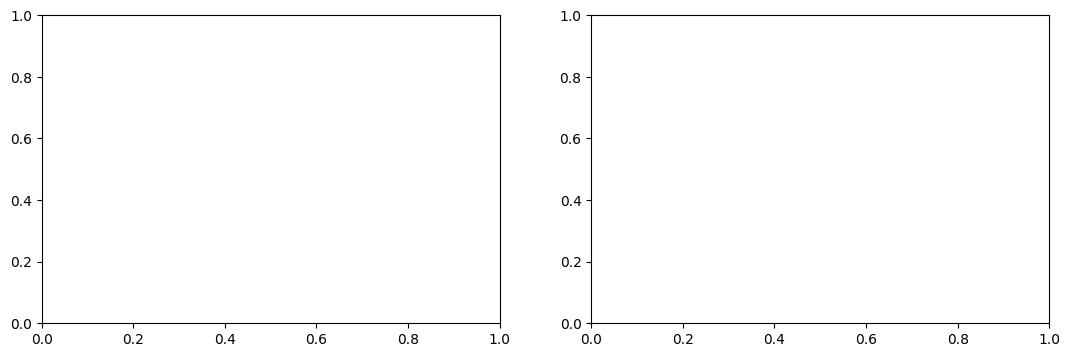

In [7]:
# ── Cell 7: Plot training history + test evaluation ───────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history["train_loss"], label="Train loss", color="#f0a500")
axes[0].plot(history["val_loss"],   label="Val loss",   color="#4fc3f7")
axes[0].set_title("Loss curves")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history["val_acc"], color="#4caf50", marker="o", ms=4)
axes[1].axhline(0.53, color="red", lw=0.8, linestyle="--",
                label="ABM baseline (53%)")
axes[1].set_title("Validation accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PROCESSED_DIR / "tft_training.png", dpi=130)
plt.show()

# ── Test set evaluation ────────────────────────────────────────────────────────
model.load_state_dict(torch.load(CHECKPOINT_DIR / "tft_best.pt",
                                 weights_only=True))
model.eval()

test_correct = test_total = 0
all_probs = []

with torch.no_grad():
    for x_batch, y_batch in test_dl:
        preds       = model(x_batch.to(device))
        predicted   = (preds > 0.5).float()
        test_correct += (predicted == y_batch.to(device)).sum().item()
        test_total   += len(y_batch)
        all_probs.extend(preds.cpu().numpy())

test_acc = test_correct / test_total
print(f"Test set accuracy  : {test_acc:.2%}")
print(f"ABM baseline       : 53.00%")
print(f"Random baseline    : 50.00%")
print(f"Delta vs ABM       : {(test_acc - 0.53)*100:+.2f}pp")
print(f"\nProb distribution  : "
      f"mean={np.mean(all_probs):.3f}  "
      f"std={np.std(all_probs):.3f}")
print("(std > 0.05 means model is making confident predictions)")
print("\n── Notebook 05 complete ──────────────────────────────────────")
print("Next: 06_combined_signal.ipynb")
print("\nCell 7 passed ✓")

In [16]:
# ── Correlation diagnostic — what actually predicts next bar direction? ────────
import pandas as pd
import numpy as np
from pathlib import Path

df = pd.read_csv(
    Path("../data_store/processed/XAUUSD_5m_historical_features.csv"),
    index_col="datetime", parse_dates=True
)

target = df["target_direction"]

print("Top correlations with next-bar direction:")
print("=" * 45)

corrs = {}
for col in df.columns:
    if col == "target_direction":
        continue
    try:
        c = df[col].corr(target)
        if not np.isnan(c):
            corrs[col] = abs(c)
    except:
        pass

top = sorted(corrs.items(), key=lambda x: x[1], reverse=True)[:20]
for name, val in top:
    bar = "█" * int(val * 500)
    print(f"  {name:<22} {val:.6f}  {bar}")

print(f"\nMax correlation : {top[0][1]:.6f}")
print(f"Min correlation : {top[-1][1]:.6f}")
print("\nIf max < 0.02 — the features have almost no linear")
print("relationship with target. Model has nothing to learn from.")

Top correlations with next-bar direction:


c:\Users\rfsga\miniconda3\envs\nexus\Lib\site-packages\numpy\lib\_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\rfsga\miniconda3\envs\nexus\Lib\site-packages\numpy\lib\_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


  rsi_7                  0.052536  ██████████████████████████
  stoch_k                0.049177  ████████████████████████
  bb_pct                 0.047679  ███████████████████████
  ema_9_ratio            0.047574  ███████████████████████
  rsi_14                 0.046954  ███████████████████████
  dist_to_high           0.044291  ██████████████████████
  return_3               0.042771  █████████████████████
  dist_to_low            0.041819  ████████████████████
  ema_21_ratio           0.041790  ████████████████████
  return_6               0.039767  ███████████████████
  return_1               0.039150  ███████████████████
  stoch_d                0.037565  ██████████████████
  return_12              0.034017  █████████████████
  ema_50_ratio           0.033069  ████████████████
  is_bullish             0.032877  ████████████████
  ll                     0.025867  ████████████
  ema_cross              0.025059  ████████████
  hh                     0.024245  ████████████
  macd_hi

In [1]:
!rocminfo | head
!rocm-smi

ROCk module version 6.16.13 is loaded
HSA System Attributes    
Runtime Version:         1.18
Runtime Ext Version:     1.15
System Timestamp Freq.:  1000.000000MHz
Sig. Max Wait Duration:  18446744073709551615 (0xFFFFFFFFFFFFFFFF) (timestamp count)
Machine Model:           LARGE                              
System Endianness:       LITTLE                             



============================================ ROCm System Management Interface ============================================
====================================================== Concise Info ======================================================
Device  Node  IDs              Temp        Power     Partitions          SCLK    MCLK     Fan  Perf  PwrCap  VRAM%  GPU%  
              (DID,     GUID)  (Junction)  (Socket)  (Mem, Compute, ID)                                                   
0       1     0x74b5,   21947  43.0°C      179.0W    NPS1, SPX, 0        155Mhz  1100Mhz  0%   auto  750.0W  0%     0%    
===========

In [2]:
!rocm-smi --setperflevel high



============================ ROCm System Management Interface ============================

================================= Set Performance Level ==================================
================================== End of ROCm SMI Log ===================================


In [3]:
import torch
print(f"PyTorch version : {torch.__version__}")
print(f"ROCm available  : {torch.cuda.is_available()}")
print(f"GPU count       : {torch.cuda.device_count()}")
if torch.cuda.is_available():
    print(f"GPU name        : {torch.cuda.get_device_name(0)}")
    props = torch.cuda.get_device_properties(0)
    print(f"VRAM            : {props.total_memory/1024**3:.0f} GB")

# Quick compute test
x = torch.randn(10000, 10000).cuda()
y = x @ x.T
print(f"Compute test    : PASSED — shape {tuple(y.shape)}")
del x, y
torch.cuda.empty_cache()

ModuleNotFoundError: No module named 'torch'